In [1]:
import sys

!{sys.executable} -m pip install scikit-learn

In [2]:
import sklearn

sklearn.__version__

'1.2.2'

In [3]:
import pandas as pd
from pathlib import Path

data_path = Path("../data/processed/telco_customer_churn_clean.csv")

df = pd.read_csv(data_path)

print("Shape:", df.shape)
print(df.head())

Shape: (7043, 36)
   customerid  count        country       state         city  zip_code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 lat_long   latitude   longitude  gender  ... monthly_charges  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...           53.85   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...           70.70   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...           99.65   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...          104.80   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...          103.70   

  total_charges churn_label  churn_value churn_sco

In [4]:
print(df["churn_value"].value_counts())
print(df["churn_value"].value_counts(normalize=True))

churn_value
0    5174
1    1869
Name: count, dtype: int64
churn_value
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [5]:
target = "churn_value"

excluded_columns = [
    "customerid",
    "churn_label",
    "churn_value",
    "churn_score",
    "churn_reason",
    "is_churned",
    "revenue_at_risk"
]

X = df.drop(columns=excluded_columns)
y = df[target]

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print("Feature count:", X.shape[1])
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Feature count: 29
Numeric features: ['count', 'zip_code', 'latitude', 'longitude', 'tenure_months', 'monthly_charges', 'total_charges', 'cltv']
Categorical features: ['country', 'state', 'city', 'lat_long', 'gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'is_month_to_month']


In [6]:
X = X.drop(columns=["count"])

X["zip_code"] = X["zip_code"].astype(str)

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print("Feature count:", X.shape[1])
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Feature count: 28
Numeric features: ['latitude', 'longitude', 'tenure_months', 'monthly_charges', 'total_charges', 'cltv']
Categorical features: ['country', 'state', 'city', 'zip_code', 'lat_long', 'gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'is_month_to_month']


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Training churn rate:", y_train.mean())
print("Testing churn rate:", y_test.mean())

Training rows: 5634
Testing rows: 1409
Training churn rate: 0.2653532126375577
Testing churn rate: 0.2654364797728886


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [9]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_probability))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7508871540099361
Precision: 0.5222437137330754
Recall: 0.7219251336898396
F1 Score: 0.606060606060606
ROC-AUC: 0.8224547262910433

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1035
           1       0.52      0.72      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409


Confusion matrix:
[[788 247]
 [104 270]]


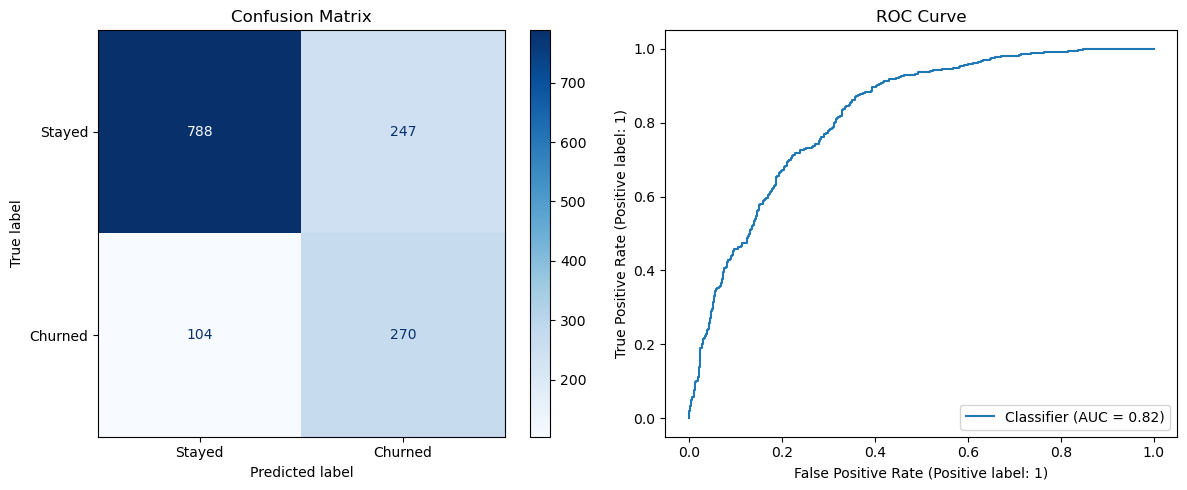

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Stayed", "Churned"],
    cmap="Blues",
    ax=axes[0]
)

RocCurveDisplay.from_predictions(
    y_test,
    y_probability,
    ax=axes[1]
)

axes[0].set_title("Confusion Matrix")
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

fitted_preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = classifier.coef_[0]

coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coefficient_table["absolute_coefficient"] = (
    coefficient_table["coefficient"].abs()
)

top_churn_drivers = (
    coefficient_table
    .sort_values("coefficient", ascending=False)
    .head(15)
)

top_retention_drivers = (
    coefficient_table
    .sort_values("coefficient", ascending=True)
    .head(15)
)

print("Features associated with higher churn probability:")
display(top_churn_drivers)

print("Features associated with lower churn probability:")
display(top_retention_drivers)

Features associated with higher churn probability:


,feature,coefficient,absolute_coefficient
4434,"categorical__lat_long_41.950683, -124.097094",1.086365,1.086365
2472,categorical__zip_code_95567,1.086365,1.086365
949,categorical__city_Smith River,1.086365,1.086365
1978,categorical__zip_code_93711,1.069420,1.069420
3628,"categorical__lat_long_36.833002, -119.82947",1.069420,1.069420
861,categorical__city_Running Springs,1.048981,1.048981
3315,"categorical__lat_long_34.186211, -117.07683",1.048981,1.048981
1611,categorical__zip_code_92382,1.048981,1.048981
307,categorical__city_Elk Grove,1.048141,1.048141
3780,"categorical__lat_long_37.556634, -122.317723",1.028276,1.028276


Features associated with lower churn probability:


,feature,coefficient,absolute_coefficient
2,numeric__tenure_months,-1.179564,1.179564
31,categorical__city_Anaheim,-0.998531,0.998531
4443,categorical__dependents_Yes,-0.956479,0.956479
369,categorical__city_Gardena,-0.891168,0.891168
64,categorical__city_Bakersfield,-0.880572,0.880572
912,categorical__city_Santa Maria,-0.856600,0.856600
85,categorical__city_Beverly Hills,-0.854055,0.854055
464,categorical__city_Irvine,-0.824347,0.824347
1049,categorical__city_Upland,-0.805660,0.805660
723,categorical__city_Orange,-0.735374,0.735374


In [ ]:
## rebuilding the model without detailed geography

In [21]:
excluded_columns = [
    "customerid",
    "churn_label",
    "churn_value",
    "churn_score",
    "churn_reason",
    "is_churned",
    "revenue_at_risk",
    "count",
    "city",
    "zip_code",
    "lat_long",
    "latitude",
    "longitude",
    "country",
    "state",
    "is_month_to_month"
]

X = df.drop(columns=excluded_columns)
y = df["churn_value"]

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print("Feature count:", X.shape[1])
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Feature count: 20
Numeric features: ['tenure_months', 'monthly_charges', 'total_charges', 'cltv']
Categorical features: ['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [24]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_probability))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7437899219304471
Precision: 0.5113438045375218
Recall: 0.7834224598930482
F1 Score: 0.6187961985216474
ROC-AUC: 0.8487690201245188

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


Confusion matrix:
[[755 280]
 [ 81 293]]


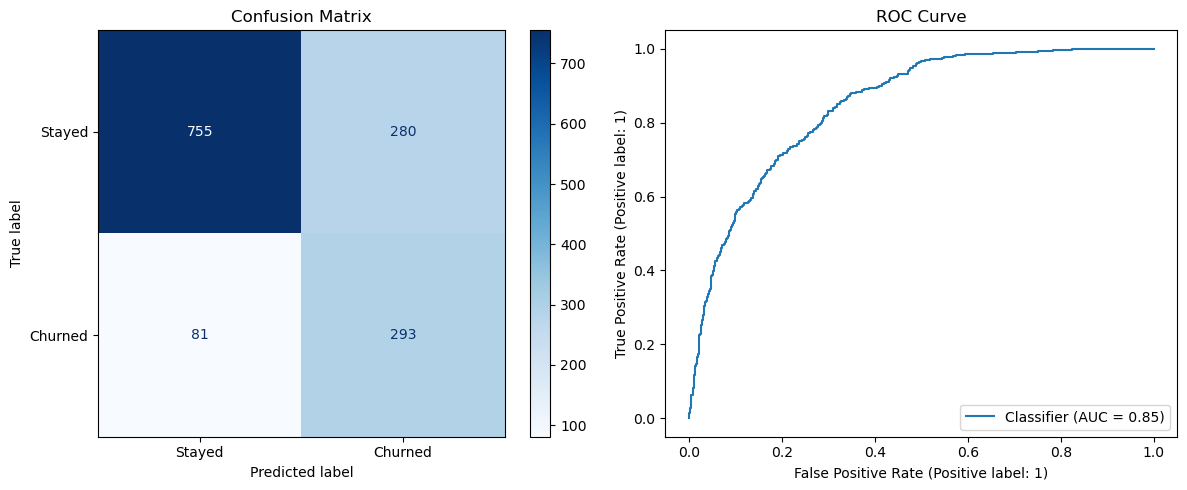

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Stayed", "Churned"],
    cmap="Blues",
    ax=axes[0]
)

RocCurveDisplay.from_predictions(
    y_test,
    y_probability,
    ax=axes[1]
)

axes[0].set_title("Confusion Matrix")
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()

In [27]:
fitted_preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = classifier.coef_[0]

coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coefficient_table["absolute_coefficient"] = (
    coefficient_table["coefficient"].abs()
)

top_churn_drivers = (
    coefficient_table
    .sort_values("coefficient", ascending=False)
    .head(15)
)

top_retention_drivers = (
    coefficient_table
    .sort_values("coefficient", ascending=True)
    .head(15)
)

print("Features associated with higher churn probability:")
display(top_churn_drivers)

print("Features associated with lower churn probability:")
display(top_retention_drivers)

Features associated with higher churn probability:


,feature,coefficient,absolute_coefficient
10,categorical__dependents_No,0.814941,0.814941
38,categorical__contract_Month-to-month,0.734751,0.734751
18,categorical__internet_service_Fiber optic,0.670180,0.670180
2,numeric__total_charges,0.485550,0.485550
37,categorical__streaming_movies_Yes,0.298922,0.298922
45,categorical__payment_method_Electronic check,0.288247,0.288247
34,categorical__streaming_tv_Yes,0.288046,0.288046
20,categorical__online_security_No,0.238736,0.238736
29,categorical__tech_support_No,0.219338,0.219338
16,categorical__multiple_lines_Yes,0.173778,0.173778


Features associated with lower churn probability:


,feature,coefficient,absolute_coefficient
0,numeric__tenure_months,-1.190981,1.190981
11,categorical__dependents_Yes,-0.818579,0.818579
40,categorical__contract_Two year,-0.681285,0.681285
1,numeric__monthly_charges,-0.564033,0.564033
17,categorical__internet_service_DSL,-0.489544,0.489544
21,categorical__online_security_No internet service,-0.184273,0.184273
24,categorical__online_backup_No internet service,-0.184273,0.184273
27,categorical__device_protection_No internet ser...,-0.184273,0.184273
30,categorical__tech_support_No internet service,-0.184273,0.184273
33,categorical__streaming_tv_No internet service,-0.184273,0.184273


In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    threshold_predictions = (
        y_probability >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "customers_flagged": threshold_predictions.sum()
    })

threshold_table = pd.DataFrame(threshold_results)
threshold_table

,threshold,precision,recall,f1_score,customers_flagged
0,0.3,0.437018,0.909091,0.590278,778
1,0.4,0.478006,0.871658,0.617424,682
2,0.5,0.511344,0.783422,0.618796,573
3,0.6,0.560417,0.719251,0.629977,480
4,0.7,0.606299,0.617647,0.611921,381


In [29]:
chosen_threshold = 0.50

all_probabilities = model.predict_proba(X)[:, 1]

scored_customers = df[
    [
        "customerid",
        "contract",
        "payment_method",
        "internet_service",
        "monthly_charges",
        "cltv",
        "churn_value"
    ]
].copy()

scored_customers["predicted_churn_probability"] = all_probabilities
scored_customers["predicted_churn"] = (
    scored_customers["predicted_churn_probability"]
    >= chosen_threshold
).astype(int)

scored_customers = scored_customers.sort_values(
    "predicted_churn_probability",
    ascending=False
)

scored_customers.head(10)

,customerid,contract,payment_method,internet_service,monthly_charges,cltv,churn_value,predicted_churn_probability,predicted_churn
886,5178-LMXOP,Month-to-month,Electronic check,Fiber optic,95.10,5795,1,0.950377,1
1582,5567-WSELE,Month-to-month,Electronic check,Fiber optic,94.60,3019,1,0.945298,1
1382,3049-SOLAY,Month-to-month,Electronic check,Fiber optic,95.20,4176,1,0.943241,1
584,7216-EWTRS,Month-to-month,Electronic check,Fiber optic,100.80,3128,1,0.942629,1
515,9497-QCMMS,Month-to-month,Electronic check,Fiber optic,93.55,5536,1,0.936872,1
716,4826-XTSOH,Month-to-month,Electronic check,Fiber optic,86.05,4843,1,0.936073,1
684,6861-XWTWQ,Month-to-month,Electronic check,Fiber optic,99.25,2487,1,0.935286,1
1255,9300-AGZNL,Month-to-month,Electronic check,Fiber optic,94.00,4176,1,0.934767,1
1682,2720-WGKHP,Month-to-month,Electronic check,Fiber optic,94.00,5569,1,0.934619,1
984,4424-TKOPW,Month-to-month,Electronic check,Fiber optic,93.85,4998,1,0.934301,1


In [30]:
predictions_path = (
    "../data/processed/customer_churn_predictions.csv"
)

scored_customers.to_csv(predictions_path, index=False)

print(f"Saved predictions to: {predictions_path}")

Saved predictions to: ../data/processed/customer_churn_predictions.csv
